# **Finding How The Data Is Distributed**


We will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 195.7 MB

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [4]:
df.isna().sum()

ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork             10631
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 114, dtype: int64

In [5]:
df = df.dropna(subset=['Employment', 'JobSat', 'YearsCodePro', 'RemoteWork']).copy()

print(df.isna().sum())

ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork                 0
                       ...  
JobSatPoints_11          115
SurveyLength             391
SurveyEase               351
ConvertedCompYearly    12313
JobSat                     0
Length: 114, dtype: int64

### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [6]:
print("Employment:")
print(df['Employment'].value_counts())

print("\nJob Satisfaction:")
print(df['JobSat'].value_counts())

print("\nYears of Professional Coding Experience:")
print(df['YearsCodePro'].value_counts())

Employment:
Employment
Employed, full-time                                                                                                                                                                                                     21900
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                                                                                                 2231
Independent contractor, freelancer, or self-employed                                                                                                                                                                     1241
Employed, part-time                                                                                                                                                                                                       530
Employed, full-time;Student, part-time                                                   

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


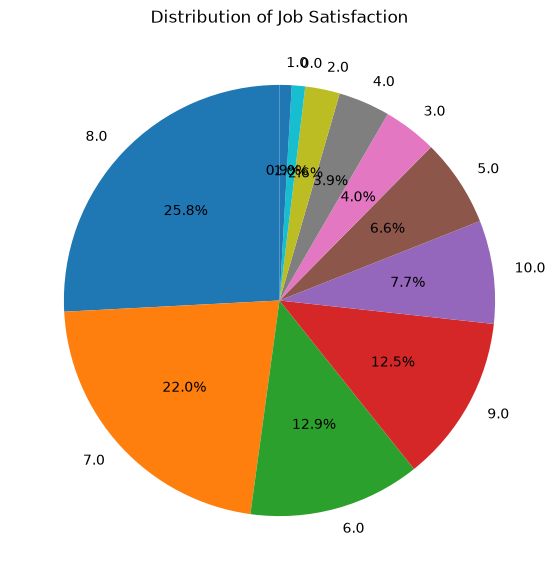

In [7]:
# Count each Job Satisfaction category
job_sat_counts = df['JobSat'].value_counts()

# Create pie chart
job_sat_counts.plot(
    kind='pie',
    figsize=(7, 7),
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Job Satisfaction')
plt.ylabel('')
plt.show()

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


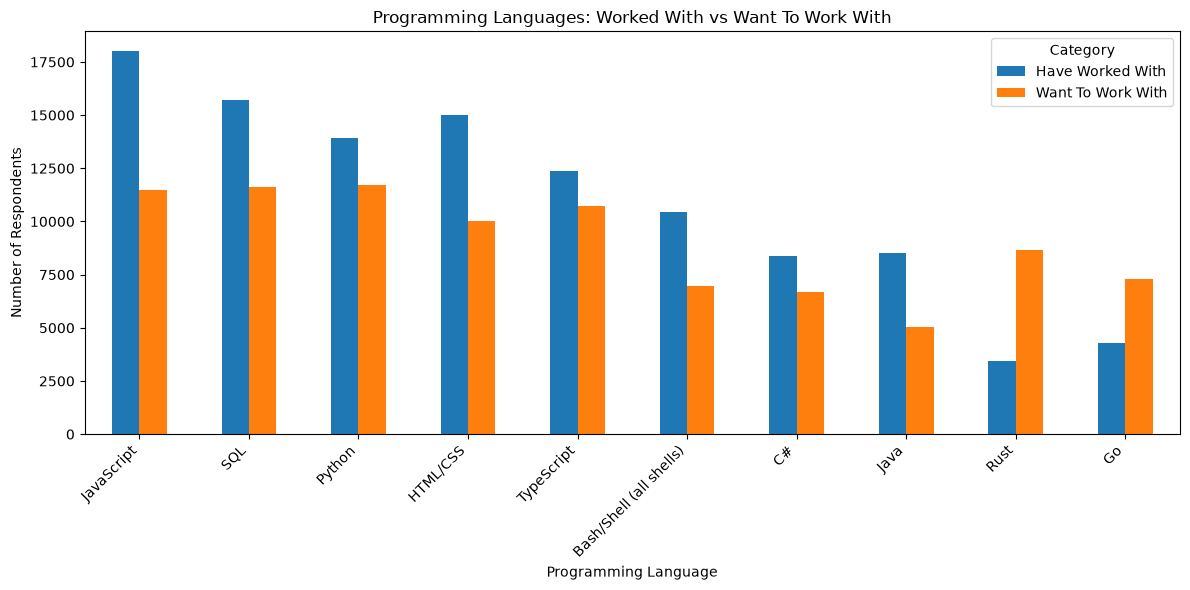

In [8]:
# Count programming languages people have worked with
worked_counts = (
    df['LanguageHaveWorkedWith']
    .dropna()
    .str.split(';')
    .explode()
    .value_counts()
)

# Count programming languages people want to work with
want_counts = (
    df['LanguageWantToWorkWith']
    .dropna()
    .str.split(';')
    .explode()
    .value_counts()
)

# Combine both counts
language_comparison = pd.DataFrame({
    'Have Worked With': worked_counts,
    'Want To Work With': want_counts
}).fillna(0)

# Select top 10 languages based on total frequency
top_languages = (
    language_comparison.sum(axis=1)
    .nlargest(10)
    .index
)

language_comparison = language_comparison.loc[top_languages]

# Plot grouped bar chart
language_comparison.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Programming Languages: Worked With vs Want To Work With')
plt.xlabel('Programming Language')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Category')
plt.tight_layout()
plt.show()

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


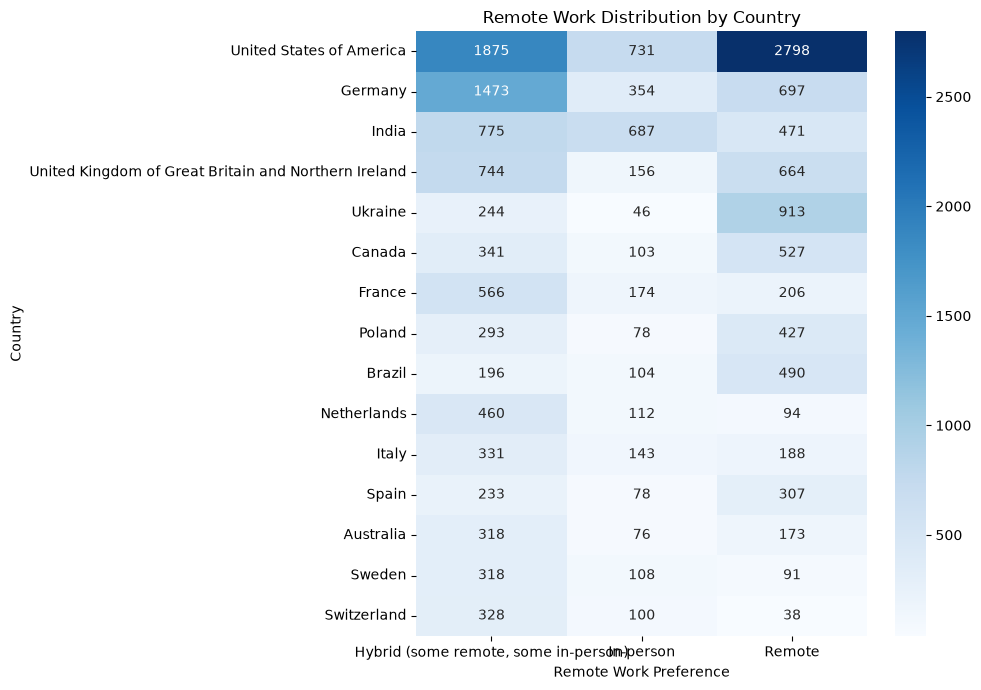

In [9]:
# Create RemoteWork counts by Country
remote_region = pd.crosstab(
    df['Country'],
    df['RemoteWork']
)

# Select top 15 countries by total respondents
top_countries = remote_region.sum(axis=1).nlargest(15).index
remote_region_top = remote_region.loc[top_countries]

# Create heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    remote_region_top,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Remote Work Distribution by Country')
plt.xlabel('Remote Work Preference')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


In [11]:
def convert_experience(x):
    if pd.isna(x):
        return None
    if 'Less than' in str(x):
        return 0.5
    if 'More than' in str(x):
        return 51
    return float(x)

df['YearsCodePro_num'] = df['YearsCodePro'].apply(convert_experience)

pearson_corr = df['JobSat'].corr(
    df['YearsCodePro_num'],
    method='pearson'
)

print("Pearson correlation:", pearson_corr)

Pearson correlation: 0.1039923682542914

### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


Employment                                          Employed, full-time  \
EdLevel                                                                   
Associate degree (A.A., A.S., etc.)                                 655   
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                      10280   
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                    6494   
Primary/elementary school                                            87   
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                     1110   
Secondary school (e.g. American high school, Ge...                  854   
Some college/university study without earning a...                 2216   
Something else                                                      204   

Employment                                          Employed, full-time;Employed, part-time  \
EdLevel                                                                                       
Associate degree (A.A., A.S., etc.)                        

/tmp/ipykernel_509/3103881566.py:27: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()

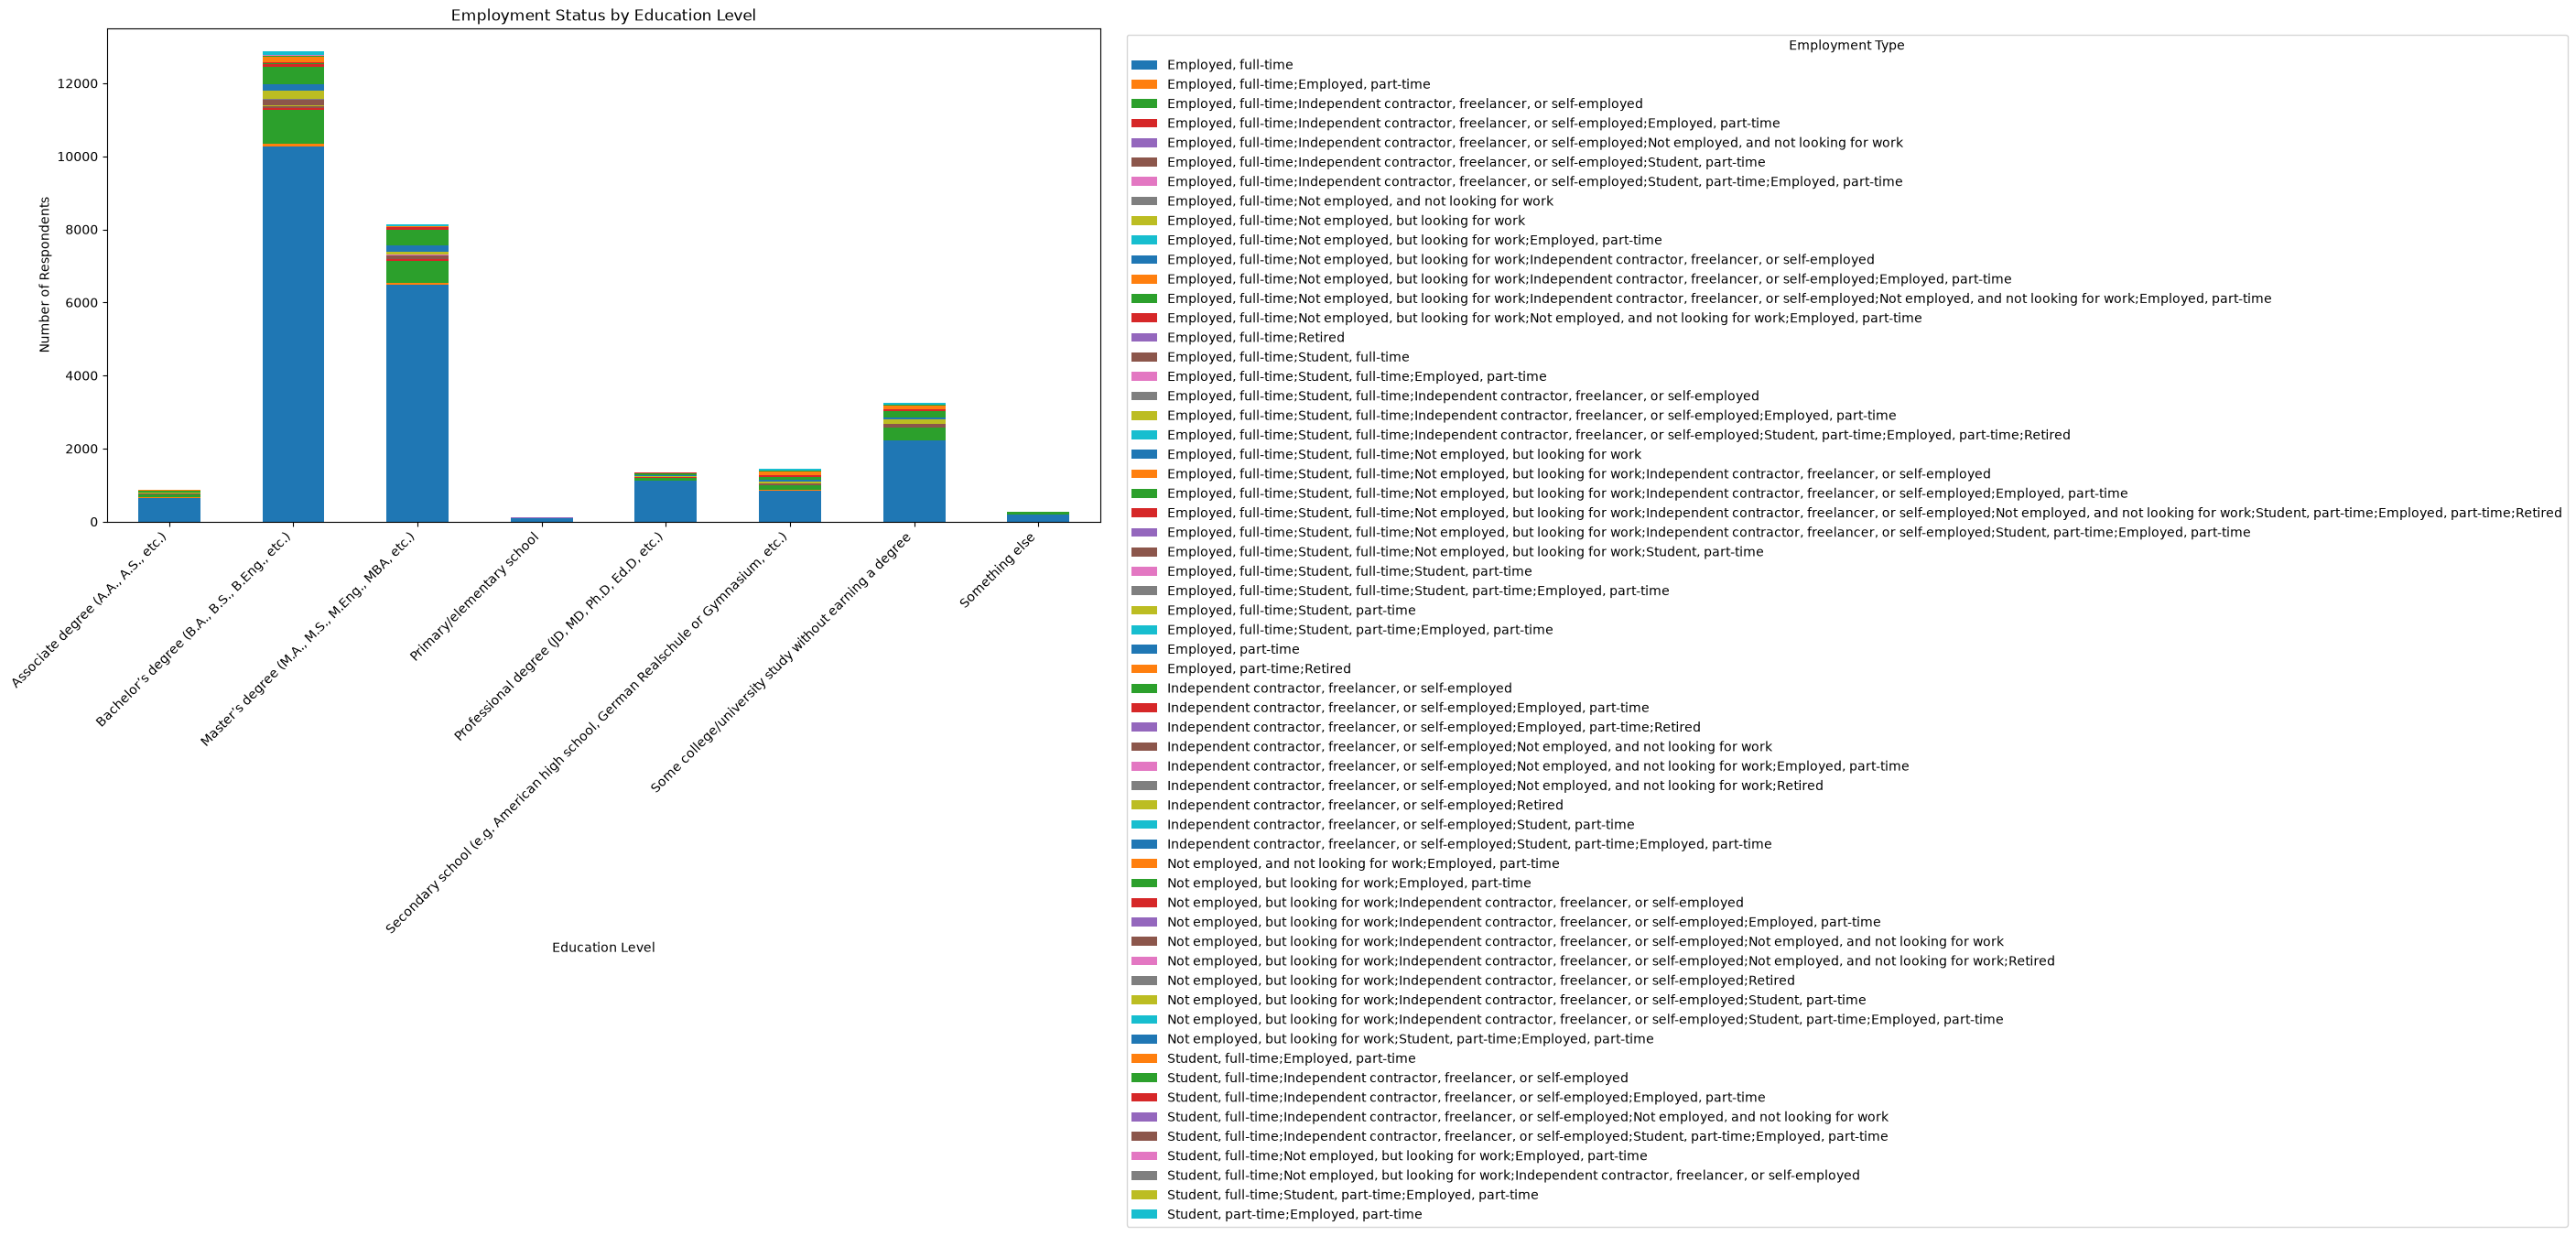

In [12]:
# Create cross-tabulation
employment_education = pd.crosstab(
    df['EdLevel'],
    df['Employment']
)

# Display the cross-tabulation
print(employment_education)

# Plot stacked bar chart
employment_education.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7)
)

plt.title('Employment Status by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.legend(
    title='Employment Type',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

you may again get a massive legend.

For a cleaner project visualization, first select the most common employment categories:

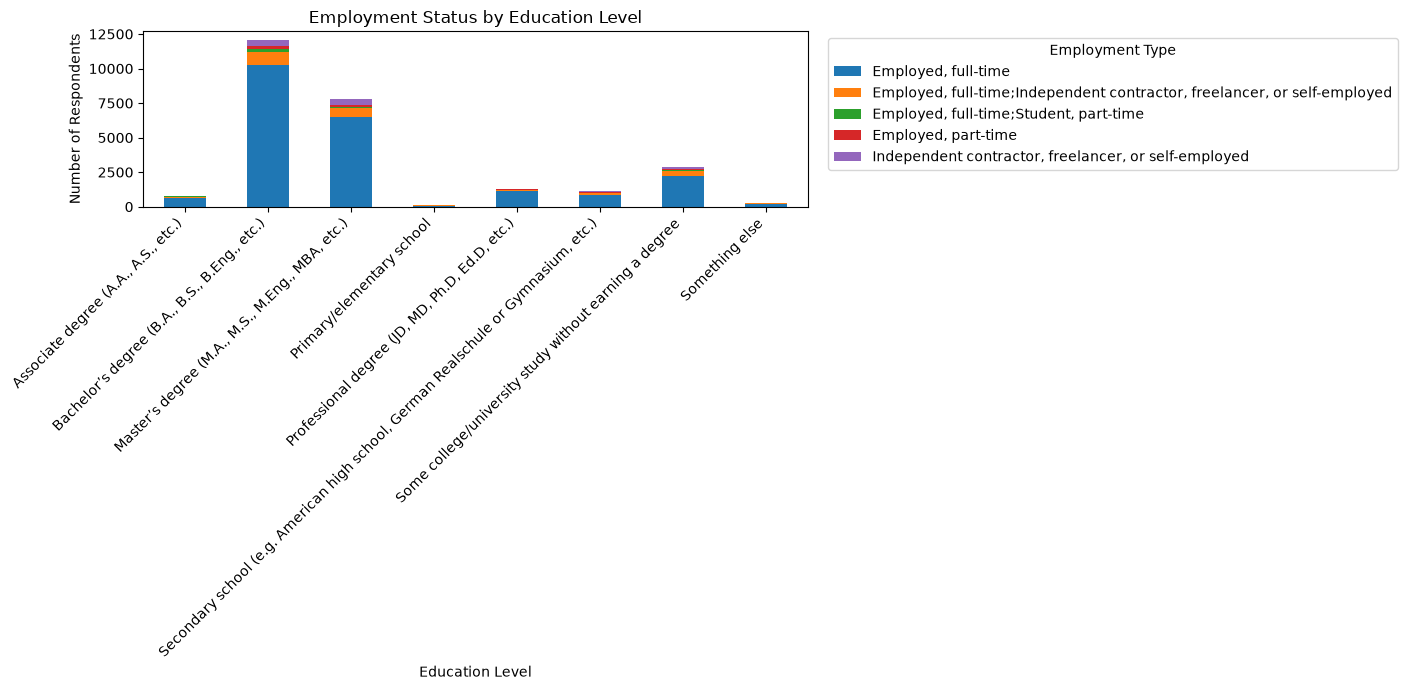

In [13]:
# Find the 5 most common employment categories
top_employment = df['Employment'].value_counts().head(5).index

df_top = df[df['Employment'].isin(top_employment)]

# Cross-tabulation
employment_education = pd.crosstab(
    df_top['EdLevel'],
    df_top['Employment']
)

# Stacked bar chart
employment_education.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7)
)

plt.title('Employment Status by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')

plt.legend(
    title='Employment Type',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [14]:
# After all cleaning and analysis
df.to_csv('stack_overflow_survey_cleaned2.csv', index=False)
print("Cleaned dataset saved successfully!")


Cleaned dataset saved successfully!

### Summary:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.
